In [2]:
%pip install pandas sqlalchemy pymysql

  Using cached pandas-3.0.0-cp314-cp314-win_amd64.whl.metadata (19 kB)
  Using cached sqlalchemy-2.0.46-cp314-cp314-win_amd64.whl.metadata (9.8 kB)
  Using cached pymysql-1.1.2-py3-none-any.whl.metadata (4.3 kB)
  Using cached greenlet-3.3.1-cp314-cp314-win_amd64.whl.metadata (3.8 kB)
Using cached pandas-3.0.0-cp314-cp314-win_amd64.whl (9.9 MB)
Using cached sqlalchemy-2.0.46-cp314-cp314-win_amd64.whl (2.1 MB)
Using cached pymysql-1.1.2-py3-none-any.whl (45 kB)
Using cached greenlet-3.3.1-cp314-cp314-win_amd64.whl (228 kB)
   ---------------------------------------- 0.0/12.4 MB ? eta -:--:--
    --------------------------------------- 0.3/12.4 MB ? eta -:--:--
   ---- ----------------------------------- 1.3/12.4 MB 5.5 MB/s eta 0:00:03
   ------ --------------------------------- 2.1/12.4 MB 4.5 MB/s eta 0:00:03
   ---------- ----------------------------- 3.1/12.4 MB 4.6 MB/s eta 0:00:03
   ------------ --------------------------- 3.9/12.4 MB 4.5 MB/s eta 0:00:02
   ---------------- ----

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import pandas as pd
pd.set_option('display.float_format', '{:.2f}'.format)
from sqlalchemy import create_engine

In [3]:
engine = create_engine(
    "mysql+pymysql://root@localhost:3306/climate_watch"
)

In [4]:
engine.connect()

In [35]:
city = pd.read_sql(
    "SELECT * FROM globallandtemperaturesbycity",
    engine
)

majorcity = pd.read_sql(
    "SELECT * FROM globallandtemperaturesbymajorcity",
    engine
)
country = pd.read_sql(
    "SELECT * FROM globallandtemperaturesbycountry",
    engine
)
state = pd.read_sql(
    "SELECT * FROM globallandtemperaturesbystate",
    engine
)
globaltemperatures = pd.read_sql(
    "SELECT * FROM globaltemperatures",
    engine
)

In [12]:
city[['AverageTemperature', 'AverageTemperatureUncertainty']].describe()


,AverageTemperature,AverageTemperatureUncertainty
count,8235007.00,8235082.00
mean,16.73,1.03
std,10.35,1.13
min,-42.70,0.03
25%,10.30,0.34
50%,18.83,0.59
75%,25.21,1.35
max,39.65,15.40


In [13]:
majorcity[['AverageTemperature', 'AverageTemperatureUncertainty']].describe()

,AverageTemperature,AverageTemperatureUncertainty
count,456346.00,456350.00
mean,18.13,0.97
std,10.02,0.98
min,-26.77,0.04
25%,12.71,0.34
50%,20.43,0.59
75%,25.92,1.32
max,38.28,14.04


In [14]:
country[['AverageTemperature', 'AverageTemperatureUncertainty']].describe()

,AverageTemperature,AverageTemperatureUncertainty
count,544804.00,545550.00
mean,17.19,1.02
std,10.95,1.20
min,-37.66,0.05
25%,10.03,0.32
50%,20.90,0.57
75%,25.81,1.21
max,38.84,15.00


In [15]:
state[['AverageTemperature', 'AverageTemperatureUncertainty']].describe()

,AverageTemperature,AverageTemperatureUncertainty
count,620012.00,620027.00
mean,8.99,1.29
std,13.77,1.36
min,-45.39,0.04
25%,-0.69,0.32
50%,11.20,0.66
75%,19.90,1.85
max,36.34,12.65


In [18]:
globaltemperatures[['LandAverageTemperature', 'LandAverageTemperatureUncertainty', 'LandMaxTemperature', ',LandMaxTemperatureUncertainty', 'LandMinTemperature', 'LandMinTemperatureUncertainty', 'LandAndOceanAverageTemperature', 'LandAndOceanAverageTemperatureUncertainty']].describe()

,LandAverageTemperature,LandAverageTemperatureUncertainty,LandMaxTemperature,",LandMaxTemperatureUncertainty",LandMinTemperature,LandMinTemperatureUncertainty,LandAndOceanAverageTemperature,LandAndOceanAverageTemperatureUncertainty
count,3193.00,3193.00,3193.00,3193.00,3193.00,3193.00,3193.00,3193.00
mean,8.34,0.93,8.95,0.30,1.71,0.27,9.49,0.08
std,4.40,1.10,7.74,0.52,3.54,0.41,7.44,0.09
min,-2.08,0.00,0.00,0.00,-5.41,0.00,0.00,0.00
25%,4.26,0.18,0.00,0.00,0.00,0.00,0.00,0.00
50%,8.58,0.39,9.35,0.12,0.00,0.14,13.86,0.06
75%,12.54,1.41,16.75,0.31,4.67,0.33,15.82,0.13
max,19.02,7.88,21.32,4.37,9.71,3.50,17.61,0.46


In [26]:
city['Date'] = pd.to_datetime(city['Date'])
city['year'] = city['Date'].dt.year
city['century'] = (city['year'] // 100) + 1
century_stats = city.groupby('century')[['AverageTemperature', 'AverageTemperatureUncertainty']].mean()
print(century_stats)

         AverageTemperature  AverageTemperatureUncertainty
century                                                   
18                    10.12                           3.70
19                    16.03                           1.54
20                    17.73                           0.45
21                    18.55                           0.37


In [27]:
majorcity['Date'] = pd.to_datetime(majorcity['Date'])
majorcity['year'] = majorcity['Date'].dt.year
majorcity['century'] = (majorcity['year'] // 100) + 1
century_stats = majorcity.groupby('century')[['AverageTemperature', 'AverageTemperatureUncertainty']].mean()
print(century_stats)

         AverageTemperature  AverageTemperatureUncertainty
century                                                   
18                    10.70                           3.44
19                    17.54                           1.52
20                    18.91                           0.47
21                    19.73                           0.39


In [28]:
country['Date'] = pd.to_datetime(country['Date'])
country['year'] = country['Date'].dt.year
country['century'] = (country['year'] // 100) + 1
century_stats = country.groupby('century')[['AverageTemperature', 'AverageTemperatureUncertainty']].mean()
print(century_stats)

         AverageTemperature  AverageTemperatureUncertainty
century                                                   
18                     9.05                           4.00
19                    15.76                           1.49
20                    18.74                           0.46
21                    19.52                           0.37


In [29]:
state['Date'] = pd.to_datetime(state['Date'])
state['year'] = state['Date'].dt.year
state['century'] = (state['year'] // 100) + 1
century_stats = state.groupby('century')[['AverageTemperature', 'AverageTemperatureUncertainty']].mean()
print(century_stats)

         AverageTemperature  AverageTemperatureUncertainty
century                                                   
18                     6.29                           3.97
19                     8.51                           1.90
20                     9.64                           0.43
21                    10.67                           0.32


In [38]:
globaltemperatures['Date'] = pd.to_datetime(globaltemperatures['Date'])
globaltemperatures['year'] = globaltemperatures['Date'].dt.year
globaltemperatures['century'] = (globaltemperatures['year'] // 100) + 1
century_stats = globaltemperatures.groupby('century')[['LandAverageTemperature', 'LandAverageTemperatureUncertainty', 'LandMaxTemperature', 'LandMaxTemperatureUncertainty', 'LandMinTemperature', 'LandMinTemperatureUncertainty', 'LandAndOceanAverageTemperature', 'LandAndOceanAverageTemperatureUncertainty']].mean()
print(century_stats)

         LandAverageTemperature  LandAverageTemperatureUncertainty  \
century                                                              
18                         8.20                               2.63   
19                         8.01                               1.01   
20                         8.64                               0.18   
21                         9.54                               0.09   

         LandMaxTemperature  LandMaxTemperatureUncertainty  \
century                                                      
18                      NaN                            NaN   
19                    13.96                           1.12   
20                    14.39                           0.22   
21                    15.29                           0.11   

         LandMinTemperature  LandMinTemperatureUncertainty  \
century                                                      
18                      NaN                            NaN   
19                  

In [40]:
pip install matplotlib

  Using cached matplotlib-3.10.8-cp314-cp314-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp314-cp314-win_amd64.whl.metadata (116 kB)
  Using cached kiwisolver-1.4.9-cp314-cp314-win_amd64.whl.metadata (6.4 kB)
  Using cached pillow-12.1.0-cp314-cp314-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp314-cp314-win_amd64.whl (8.3 MB)
Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl (232 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.61.1-cp314-cp314-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.4.9-cp314-cp314-win_amd64.whl (75 kB)
Using cached pillow-12.1.0-cp314-cp314-win_amd64.whl (7.2 MB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

   ---------------------------------------- 0/7 [pyparsing]
   -

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


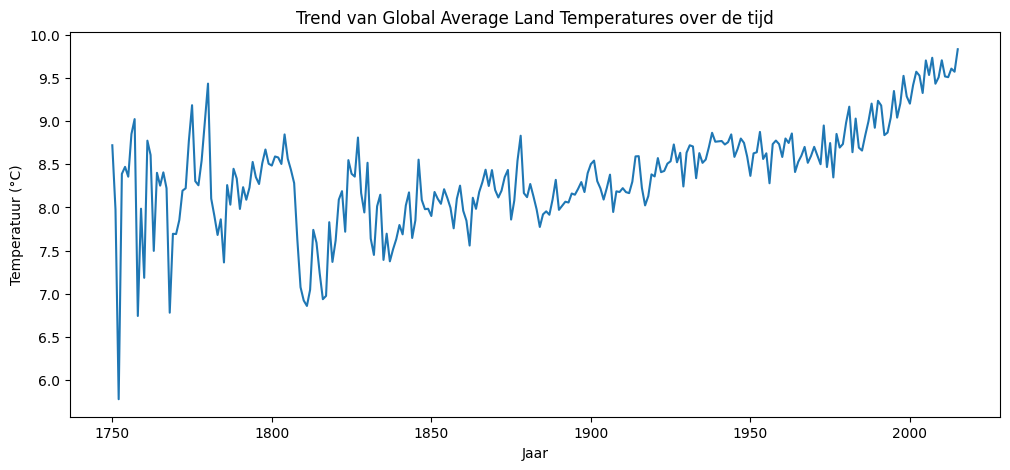

In [45]:
import matplotlib.pyplot as plt

globaltemperature_per_jaar = globaltemperatures.groupby('year')[[
    'LandAverageTemperature'
]].mean()

plt.figure(figsize=(12,5))

plt.plot(globaltemperature_per_jaar.index,
         globaltemperature_per_jaar['LandAverageTemperature'])

plt.title("Trend van Global Average Land Temperatures over de tijd")
plt.xlabel("Jaar")
plt.ylabel("Temperatuur (°C)")

plt.show()